In [1]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import numpy as np
from scipy.stats import binned_statistic, binned_statistic_2d
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from src.loading import *
from src.utils import *

In [21]:
# Load PCs and normalize them by std dev
#
pcs = load_gsam_eofs_pcs().scores()
pcs = pcs/pcs.std(('lat', 'lon', 'time'))
# Compute phase angle, phase number, and radius
# Where radius < 0.5, we set phase number to 0
#
theta = np.arctan2(pcs.sel(mode=2), pcs.sel(mode=1))
radius = np.sqrt(pcs.sel(mode=2)**2 + pcs.sel(mode=1)**2)
# Load std of vertical vel
#
std_mf = load_coarse_std_gsam_w() * load_gsam_reference_profiles().rho
std_mf = std_mf.mean('z')
# Only look at values of theta that fall between -pi/4 and pi/4
#
convective_regime_mask = (radius >= 0.5) & (-np.pi/2 <= theta) & (theta <= np.pi/2)
theta = theta.where(convective_regime_mask, np.nan, drop=False)
radius = radius.where(convective_regime_mask, np.nan, drop=False)
# Compute change in theta (centered difference)
#
initial_theta = theta.isel(time=slice(0, -2)).data
final_theta = theta.isel(time=slice(2, None)).data
delta_theta_data= (final_theta - initial_theta)/3
delta_theta = theta.isel(time=slice(1, -1)).copy(data=delta_theta_data)
# Compute change in radius (centered difference)
#
initial_radius = radius.isel(time=slice(0, -2)).data
final_radius = radius.isel(time=slice(2, None)).data
delta_radius_data= (final_radius - initial_radius)/3
delta_radius = radius.isel(time=slice(1, -1)).copy(data=delta_radius_data)

# Trim radius data
#
radius = radius.sel(time=delta_theta.time)
theta = theta.sel(time=delta_theta.time)
std_mf = std_mf.sel(time=delta_theta.time)

/var/folders/1t/6drgwyc17q12xmq4h7m454vw0000gn/T/ipykernel_92882/2127518698.py:14: RuntimeWarning: Mean of empty slice
  statistic=lambda x: np.nanmean(x) if x.size>OBS_THRESH else np.nan,


Text(0.5, 1.0, 'Mean $\\Delta \\theta_{cs}$ [rad]')

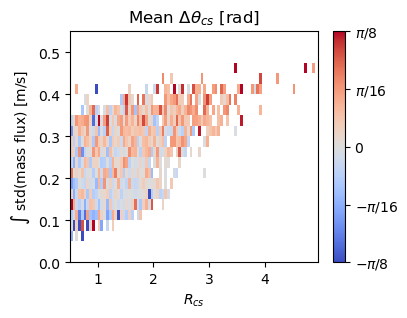

In [22]:
# Compute the mean delta binned by R and theta
#
OBS_THRESH = 5
radius_bins = np.arange(0.5, 5, 0.05)
std_bins = np.arange(0, 1, 0.025)
assert(radius.shape==theta.shape)
# Bin data by theta and radius
#
var_to_bin = delta_theta
bin_mean = binned_statistic_2d(
    std_mf.data.ravel(), 
    radius.data.ravel(),
    var_to_bin.data.ravel(),
    statistic=lambda x: np.nanmean(x) if x.size>OBS_THRESH else np.nan,
    bins=[std_bins, radius_bins]
).statistic

# Plot the data
#
fig, ax = plt.subplots(figsize=(4, 3))
xx, yy = np.meshgrid(array_midpoints(radius_bins), array_midpoints(std_bins))
c = ax.pcolormesh(
    xx, yy,
    bin_mean,
    norm=colors.TwoSlopeNorm(vmin=-np.pi/8, vmax=np.pi/8, vcenter=0),
    cmap=plt.cm.coolwarm
)
cb = fig.colorbar(c)
ticks = [-np.pi/8, -np.pi/16, 0, np.pi/16, np.pi/8]
cb.set_ticks(ticks)
cb.set_ticklabels([r"$-\pi/8$", r"$-\pi/16$", "0", r"$\pi/16$", r"$\pi/8$"])
ax.set_ylim(0, 0.55)

ax.set_xlabel(r'$R_{cs}$')
ax.set_ylabel(r"$\int$ std(mass flux) [m/s]")
ax.set_title(r'Mean $\Delta \theta_{cs}$ [rad]')


/var/folders/1t/6drgwyc17q12xmq4h7m454vw0000gn/T/ipykernel_92882/4106877511.py:14: RuntimeWarning: Mean of empty slice
  statistic=lambda x: np.nanmean(x) if x.size>OBS_THRESH else np.nan,


Text(0.5, 1.0, 'Mean $\\Delta R_{cs}$ [made up units]')

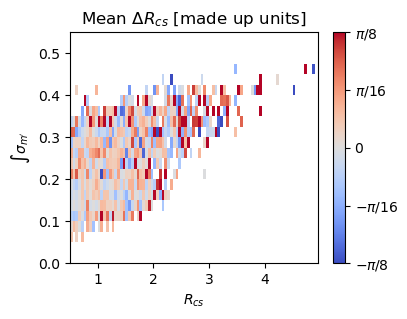

In [13]:
# Compute the mean delta binned by R and theta
#
OBS_THRESH = 5
radius_bins = np.arange(0.5, 5, 0.05)
std_bins = np.arange(0, 1, 0.025)
assert(radius.shape==theta.shape)
# Bin data by theta and radius
#
var_to_bin = delta_radius
bin_mean = binned_statistic_2d(
    std_mf.data.ravel(), 
    radius.data.ravel(),
    var_to_bin.data.ravel(),
    statistic=lambda x: np.nanmean(x) if x.size>OBS_THRESH else np.nan,
    bins=[std_bins, radius_bins]
).statistic

# Plot the data
#
fig, ax = plt.subplots(figsize=(4, 3))
xx, yy = np.meshgrid(array_midpoints(radius_bins), array_midpoints(std_bins))
c = ax.pcolormesh(
    xx, yy,
    bin_mean,
    norm=colors.TwoSlopeNorm(vmin=-np.pi/8, vmax=np.pi/8, vcenter=0),
    cmap=plt.cm.coolwarm
)
cb = fig.colorbar(c)
ticks = [-np.pi/8, -np.pi/16, 0, np.pi/16, np.pi/8]
cb.set_ticks(ticks)
cb.set_ticklabels([r"$-\pi/8$", r"$-\pi/16$", "0", r"$\pi/16$", r"$\pi/8$"])
ax.set_ylim(0, 0.55)

ax.set_xlabel(r'$R_{cs}$')
ax.set_ylabel(r"$\int \sigma_{m'}$")
ax.set_title(r'Mean $\Delta R_{cs}$ [made up units]')


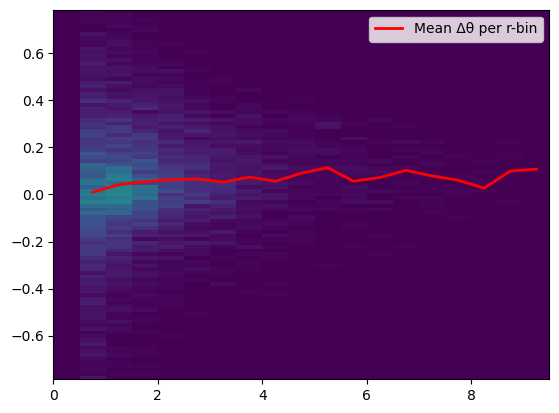

In [111]:
OBS_THRESH = 10
r_bins = np.arange(0, 10, 0.5)
delta_theta_bins = np.linspace(-np.pi/4, np.pi/4, 100)
count = binned_statistic_2d(
    delta_theta.data.ravel(),
    radius.data.ravel(),
    None,
    statistic='count',
    bins=[delta_theta_bins, r_bins]    
).statistic

fig, ax = plt.subplots()
xx, yy = np.meshgrid(array_midpoints(r_bins), array_midpoints(delta_theta_bins))
ax.pcolormesh(xx, yy, 100*count/count.sum(), norm=colors.Normalize(vmin=0.01, vmax=2))


theta_centers = array_midpoints(delta_theta_bins)           # (n_theta_bins,)
r_centers     = array_midpoints(r_bins)                     # (n_r_bins,)

# Mean Δθ per r-bin (weighted by counts in each θ-bin)
col_totals = count.sum(axis=0)                              # (n_r_bins,)
mean_theta = np.full_like(r_centers, np.nan, dtype=float)   # init

valid = col_totals > 0
mean_theta[valid] = (theta_centers[:, None] * count)[:, valid].sum(axis=0) / col_totals[valid]

# Overlay
ax.plot(r_centers, mean_theta, linewidth=2, label='Mean Δθ per r-bin', color='red')
ax.legend()
# ax.set_ylim(-np.pi/8, np.pi/8)

Text(0, 0.5, 'Δθ')

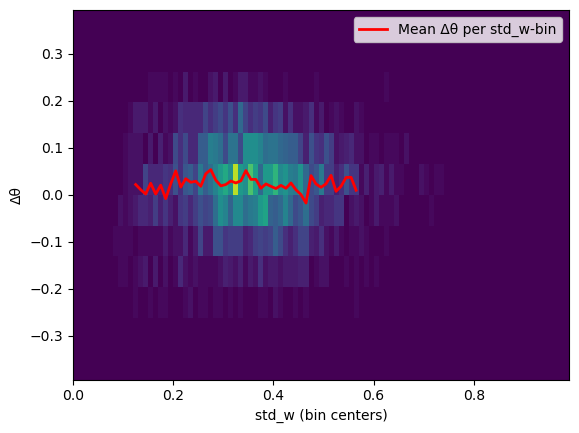

In [106]:
# Now bin by std w
#
OBS_THRESH = 10
std_w_bins = np.arange(0, 1, 0.01)
delta_theta_bins = np.linspace(-np.pi/4, np.pi/4, 25)
count = binned_statistic_2d(
    delta_theta.data.ravel(),
    std_w.data.ravel(),
    None,
    statistic='count',
    bins=[delta_theta_bins, std_w_bins]    
).statistic

fig, ax = plt.subplots()
xx, yy = np.meshgrid(array_midpoints(std_w_bins), array_midpoints(delta_theta_bins))
ax.pcolormesh(xx, yy, 100*count/count.sum(), norm=colors.Normalize(vmin=0.001, vmax=2))

# Bin centers
theta_centers = array_midpoints(delta_theta_bins)           # (n_theta_bins,)
w_centers     = array_midpoints(std_w_bins)                 # (n_w_bins,)

# Mean Δθ per std_w-bin (weighted by counts in each θ-bin)
col_totals = count.sum(axis=0)                              # (n_w_bins,)
mean_theta = np.full_like(w_centers, np.nan, dtype=float)

valid = col_totals >= OBS_THRESH                            # use threshold
mean_theta[valid] = (theta_centers[:, None] * count)[:, valid].sum(axis=0) / col_totals[valid]

# Overlay
ax.plot(w_centers, mean_theta, linewidth=2, label='Mean Δθ per std_w-bin', color='red')
ax.legend()
ax.set_ylim(-np.pi/8, np.pi/8)
ax.set_xlabel('std_w (bin centers)')
ax.set_ylabel('Δθ')
